# PatchTST: Goldkursanalyse

## Optionale Installation

Falls einzelne Pakete in Ihrer Umgebung fehlen, installiert die nächste Zelle sie automatisch. In bereits vorbereiteten Kursumgebungen ist dieser Schritt meist schnell oder es passiert nichts.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "torch": "torch",
}

missing_packages = [
    package_name
    for import_name, package_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are already available.")

All required packages are already available.


In [2]:
import math
import random
import warnings
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Data Understanding

Wir verwenden den öffentlich verfügbaren **ETTh1-Datensatz** aus der Electricity Transformer Temperature Collection. Der Datensatz enthält stündliche Messungen eines Stromtransformators, darunter Last- und Temperaturvariablen.

Warum eignet sich dieser Datensatz für PatchTST?

- Er ist eine echte, regelmäßig gemessene Zeitreihe.
- Er enthält mehrere numerische Kanäle.
- Er besitzt genügend Länge für Sliding Windows und Patches.
- Die Zielvariable `OT` wird häufig für Long-Term-Forecasting-Beispiele verwendet.
- Saisonale Muster und Trends sind visuell diskutierbar.

In [3]:
import pandas as pd

df = pd.read_csv("../Data/goldpreis_seit_2000_prep.csv")

df["Date"] = pd.to_datetime(df["Date"],utc=True)
df = df.sort_values("Date").reset_index(drop=True)

print(df.shape)
display(df.head())
display(df.tail())

(6491, 10)


,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Change %
0,0,2000-09-01 04:00:00+00:00,277.000000,277.000000,277.000000,277.000000,0,0.0,0.0,0.000000
1,1,2000-09-05 04:00:00+00:00,275.799988,275.799988,275.799988,275.799988,2,0.0,0.0,-0.004332
2,2,2000-09-06 04:00:00+00:00,274.200012,274.200012,274.200012,274.200012,0,0.0,0.0,-0.005801
3,3,2000-09-07 04:00:00+00:00,274.000000,274.000000,274.000000,274.000000,125,0.0,0.0,-0.000729
4,4,2000-09-08 04:00:00+00:00,273.299988,273.299988,273.299988,273.299988,0,0.0,0.0,-0.002555


,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Change %
6486,6486,2026-07-13 04:00:00+00:00,4081.000000,4081.000000,3985.899902,3997.000000,679,0.0,0.0,-0.026096
6487,6487,2026-07-14 04:00:00+00:00,3995.699951,4091.199951,3986.500000,4061.100098,1281,0.0,0.0,0.016037
6488,6488,2026-07-15 04:00:00+00:00,4049.100098,4070.100098,4019.399902,4044.000000,374,0.0,0.0,-0.004211
6489,6489,2026-07-16 04:00:00+00:00,4030.500000,4030.500000,3972.600098,3985.600098,374,0.0,0.0,-0.014441
6490,6490,2026-07-17 04:00:00+00:00,3980.100098,4012.199951,3963.000000,3999.199951,70785,0.0,0.0,0.003412


### Spalten und Zeitindex

Jede Zeile repräsentiert eine Stunde. Die Spalte `date` ist der Zeitstempel. Alle übrigen Spalten sind numerische Messgrößen. Wir verwenden später `OT` als Zielvariable, behalten aber auch die anderen numerischen Variablen als zusätzliche Kanäle.

In [4]:
print(df.info())
print("\nColumns:", list(df.columns))
print("Time range:", df["Date"].min(), "to", df["Date"].max())
print("Median time difference:", df["Date"].diff().median())

<class 'pandas.DataFrame'>
RangeIndex: 6491 entries, 0 to 6490
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   Unnamed: 0    6491 non-null   int64              
 1   Date          6491 non-null   datetime64[us, UTC]
 2   Open          6491 non-null   float64            
 3   High          6491 non-null   float64            
 4   Low           6491 non-null   float64            
 5   Close         6491 non-null   float64            
 6   Volume        6491 non-null   int64              
 7   Dividends     6491 non-null   float64            
 8   Stock Splits  6491 non-null   float64            
 9   Change %      6491 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(7), int64(2)
memory usage: 507.2 KB
None

Columns: ['Unnamed: 0', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Change %']
Time range: 2000-09-01 04:00:00+00:00 to 2026-0

## 3. Data Preparation

Wir bereiten die Daten so vor, dass keine Information aus der Zukunft ins Training gelangt:

- Split nach Zeitreihenfolge, nicht zufällig.
- Normalisierung nur mit Statistiken des Trainingsbereichs.
- Sliding Windows für Eingabe und Prognoseziel.
- Tensoren im Format `(samples, lookback, channels)` und `(samples, horizon, channels)`.

Wichtige Begriffe:

- **Lookback window:** Wie viele vergangene Zeitschritte das Modell sieht.
- **Forecast horizon:** Wie viele zukünftige Zeitschritte das Modell vorhersagt.

In [5]:
target_column = "Close"
feature_columns = target_column
target_index = feature_columns.index(target_column)

lookback = 96
horizon = 24
patch_length = 16
stride = 8

values = df["Close"].astype("float32").values
dates = df["Date"].values

train_end = int(len(values) * 0.70)
validation_end = int(len(values) * 0.85)

train_values_raw = values[:train_end]
validation_values_raw = values[train_end:validation_end]
test_values_raw = values[validation_end:]

train_dates = dates[:train_end]
validation_dates = dates[train_end:validation_end]
test_dates = dates[validation_end:]

train_mean = train_values_raw.mean(axis=0, keepdims=True)
train_std = train_values_raw.std(axis=0, keepdims=True)
train_std = np.where(train_std == 0, 1.0, train_std)

train_values = (train_values_raw - train_mean) / train_std
validation_values = (validation_values_raw - train_mean) / train_std
test_values = (test_values_raw - train_mean) / train_std

print("Train rows:", train_values.shape)
print("Validation rows:", validation_values.shape)
print("Test rows:", test_values.shape)
print("Number of channels:", len(feature_columns))

Train rows: (4543,)
Validation rows: (974,)
Test rows: (974,)
Number of channels: 5


### Sliding Windows

Ein Sliding Window erzeugt viele Trainingsbeispiele aus einer langen Zeitreihe. Für jedes Beispiel nimmt man einen Vergangenheitsblock der Länge `lookback` und den direkt folgenden Zukunftsblock der Länge `horizon`.

Mathematisch:

\[
X_i = [x_i, x_{i+1}, \dots, x_{i+L-1}]
\]

\[
y_i = [x_{i+L}, x_{i+L+1}, \dots, x_{i+L+H-1}]
\]

Dabei ist \(L\) die Lookback-Länge und \(H\) der Prognosehorizont.

In [6]:
def create_sliding_windows(data, lookback_length, horizon_length):
    # Create input and target windows from a multivariate time series.
    inputs = []
    targets = []
    max_start = len(data) - lookback_length - horizon_length + 1

    for start in range(max_start):
        end = start + lookback_length
        target_end = end + horizon_length
        inputs.append(data[start:end])
        targets.append(data[end:target_end])

    return np.stack(inputs).astype("float32"), np.stack(targets).astype("float32")


X_train, y_train = create_sliding_windows(train_values, lookback, horizon)
X_validation, y_validation = create_sliding_windows(validation_values, lookback, horizon)
X_test, y_test = create_sliding_windows(test_values, lookback, horizon)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4424, 96)
y_train: (4424, 24)
X_validation: (855, 96)
y_validation: (855, 24)
X_test: (855, 96)
y_test: (855, 24)


In [7]:
#tensor_3d = X_train[None, :, :]
X_train = X_train[:, :, np.newaxis]
y_train = y_train[:, :, np.newaxis]
X_validation =  X_validation[:, :, np.newaxis]
y_validation = y_validation[:, :, np.newaxis]
X_test = X_test[:, :, np.newaxis]
y_test = y_test[:, :, np.newaxis]

print("X_train:",X_train.shape)      
print("y_train:", y_train.shape)
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (4424, 96, 1)
y_train: (4424, 24, 1)
X_validation: (855, 96, 1)
y_validation: (855, 24, 1)
X_test: (855, 96, 1)
y_test: (855, 24, 1)


### Patch-Anzahl und Tensorformen

Die Anzahl der Patches ergibt sich aus:

\[
N_\text{patches} = \left\lfloor \frac{L - P}{S} \right\rfloor + 1
\]

Dabei ist \(L\) die Lookback-Länge, \(P\) die Patch-Länge und \(S\) der Stride.

In [8]:
def count_patches(sequence_length, patch_size, patch_stride):
    # Compute the number of patches for a sequence.
    return ((sequence_length - patch_size) // patch_stride) + 1


num_patches = count_patches(lookback, patch_length, stride)
print("Lookback:", lookback)
print("Patch length:", patch_length)
print("Stride:", stride)
print("Number of patches:", num_patches)

Lookback: 96
Patch length: 16
Stride: 8
Number of patches: 11


## 5. Modeling

Wir implementieren eine kleine, lesbare PatchTST-Variante in PyTorch. Sie ist bewusst kompakt:

- Patching mit `unfold`
- lineares Patch Embedding
- lernbare Positionskodierung
- Transformer Encoder
- lineare Vorhersage für den Forecast Horizon

Die Ausgabe hat die Form `(batch, horizon, channels)`.

In [9]:
@dataclass
class PatchTSTConfig:
    lookback: int
    horizon: int
    num_channels: int
    patch_length: int
    stride: int
    d_model: int = 64
    n_heads: int = 4
    num_layers: int = 2
    dropout: float = 0.10

    @property
    def num_patches(self):
        return ((self.lookback - self.patch_length) // self.stride) + 1


class EducationalPatchTST(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.patch_embedding = nn.Linear(config.patch_length, config.d_model)
        self.position_embedding = nn.Parameter(torch.zeros(1, config.num_patches, config.d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.d_model,
            nhead=config.n_heads,
            dim_feedforward=config.d_model * 4,
            dropout=config.dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=config.num_layers)
        self.dropout = nn.Dropout(config.dropout)
        self.prediction_head = nn.Linear(config.num_patches * config.d_model, config.horizon)

    def forward(self, x, print_shapes=False):
        # Run a channel-independent PatchTST forward pass.
        batch_size, lookback_length, num_channels = x.shape

        if print_shapes:
            print(f"Input: {x.shape} -> (batch, lookback, channels) = ({batch_size}, {lookback_length}, {num_channels})")

        x = x.permute(0, 2, 1)
        x = x.reshape(batch_size * num_channels, lookback_length)

        patches = x.unfold(dimension=-1, size=self.config.patch_length, step=self.config.stride)

        if print_shapes:
            print(f"Patches: {patches.shape} -> (batch * channels, num_patches, patch_length) = ({batch_size} * {num_channels}, {self.config.num_patches}, {self.config.patch_length})")

        embedded = self.patch_embedding(patches)
        embedded = embedded + self.position_embedding
        embedded = self.dropout(embedded)

        if print_shapes:
            print(f"Embedded patches: {embedded.shape} -> each raw patch is projected from length {self.config.patch_length} to d_model={self.config.d_model}")

        encoded = self.encoder(embedded)

        if print_shapes:
            print(f"Encoded patches: {encoded.shape} -> Transformer keeps the same shape but enriches each patch with attention context")

        flattened = encoded.reshape(batch_size * num_channels, -1)
        forecast = self.prediction_head(flattened)
        forecast = forecast.reshape(batch_size, num_channels, self.config.horizon)
        forecast = forecast.permute(0, 2, 1)

        if print_shapes:
            print(f"Forecast: {forecast.shape} -> (batch, horizon, channels) = ({batch_size}, {self.config.horizon}, {num_channels})")

        return forecast


config = PatchTSTConfig(
    lookback=lookback,
    horizon=horizon,
    num_channels=len(feature_columns),
    patch_length=patch_length,
    stride=stride,
)

model = EducationalPatchTST(config).to(device)
print(config)
print("d_model=64: each patch token is represented by 64 learned features.")
print("n_heads=4: attention is split into 4 heads, each looking at patch relations differently.")
print("num_layers=2: two Transformer encoder blocks are stacked.")
print("dropout=0.1: 10% of selected activations are dropped during training to reduce overfitting.")
print("Trainable parameters:", sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad))

PatchTSTConfig(lookback=96, horizon=24, num_channels=5, patch_length=16, stride=8, d_model=64, n_heads=4, num_layers=2, dropout=0.1)
d_model=64: each patch token is represented by 64 learned features.
n_heads=4: attention is split into 4 heads, each looking at patch relations differently.
num_layers=2: two Transformer encoder blocks are stacked.
dropout=0.1: 10% of selected activations are dropped during training to reduce overfitting.
Trainable parameters: 118680


### Sanity Check der Tensorformen

Bevor wir trainieren, schicken wir einen kleinen Batch durch das Modell. So sehen wir die wichtigsten Formen der PatchTST-Pipeline.

In [ ]:
#Nicht verwenden!!!
#sample_batch = torch.tensor(y_train[:4], dtype=torch.float32).to(device)
#with torch.no_grad():
 #   sample_output = model(sample_batch, print_shapes=True)

#assert sample_output.shape == (2, horizon, len(feature_columns))

Input: torch.Size([4, 24, 1]) -> (batch, lookback, channels) = (4, 24, 1)
Patches: torch.Size([4, 2, 16]) -> (batch * channels, num_patches, patch_length) = (4 * 1, 11, 16)


RuntimeError: The size of tensor a (2) must match the size of tensor b (11) at non-singleton dimension 1

### DataLoader

Für eine schnelle Demonstration begrenzen wir die Anzahl der Trainingsfenster. Der Testbereich bleibt unverändert. In einer ernsthaften Modellierung würde man mehr Epochen, Hyperparameter-Suche und eventuell den vollständigen Trainingsbereich verwenden.

In [11]:
#max_train_windows = 2500
##max_validation_windows = 800
batch_size = 64

#X_train_small = X_train[:max_train_windows]
#y_train_small = y_train[:max_train_windows]
#X_validation_small = X_validation[:max_validation_windows]
#y_validation_small = y_validation[:max_validation_windows]

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32),
)
validation_dataset = TensorDataset(
    torch.tensor(X_validation, dtype=torch.float32),
    torch.tensor(y_validation, dtype=torch.float32),
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32),
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Training batches: 70
Validation batches: 14
Test batches: 14


### Training Loop

Wir trainieren mit AdamW und MSELoss. Die Loss wird auf alle Kanäle berechnet. Für die spätere Interpretation konzentrieren wir uns auf die Zielvariable `OT`.

In [12]:
def run_one_epoch(model, data_loader, criterion, optimizer=None):
    # Train or evaluate one epoch.
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_observations = 0

    for batch_inputs, batch_targets in data_loader:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        if is_training:
            optimizer.zero_grad()

        predictions = model(batch_inputs)
        loss = criterion(predictions, batch_targets)

        if is_training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        batch_size_current = batch_inputs.size(0)
        total_loss += loss.item() * batch_size_current
        total_observations += batch_size_current

    return total_loss / total_observations


criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 100
training_losses = []
validation_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = run_one_epoch(model, train_loader, criterion, optimizer)
    validation_loss = run_one_epoch(model, validation_loader, criterion, optimizer=None)

    training_losses.append(train_loss)
    validation_losses.append(validation_loss)

    print(f"Epoch {epoch:02d} | train loss: {train_loss:.4f} | validation loss: {validation_loss:.4f}")

Epoch 01 | train loss: 0.1001 | validation loss: 0.0800
Epoch 02 | train loss: 0.0335 | validation loss: 0.0354
Epoch 03 | train loss: 0.0246 | validation loss: 0.0952
Epoch 04 | train loss: 0.0213 | validation loss: 0.0747
Epoch 05 | train loss: 0.0218 | validation loss: 0.0557
Epoch 06 | train loss: 0.0174 | validation loss: 0.0569
Epoch 07 | train loss: 0.0160 | validation loss: 0.0449
Epoch 08 | train loss: 0.0158 | validation loss: 0.0517
Epoch 09 | train loss: 0.0142 | validation loss: 0.0781
Epoch 10 | train loss: 0.0135 | validation loss: 0.0607
Epoch 11 | train loss: 0.0137 | validation loss: 0.0633
Epoch 12 | train loss: 0.0119 | validation loss: 0.0761
Epoch 13 | train loss: 0.0120 | validation loss: 0.0932
Epoch 14 | train loss: 0.0130 | validation loss: 0.0689
Epoch 15 | train loss: 0.0111 | validation loss: 0.0881
Epoch 16 | train loss: 0.0121 | validation loss: 0.0848
Epoch 17 | train loss: 0.0112 | validation loss: 0.1173
Epoch 18 | train loss: 0.0122 | validation loss:

### Trainingsverlauf

Der Trainings- und Validierungsverlust zeigt, ob das Modell lernt und ob es stark überangepasst wirkt. Bei wenigen Epochen erwarten wir keine perfekte Prognose, aber eine fallende Tendenz ist ein gutes Zeichen.

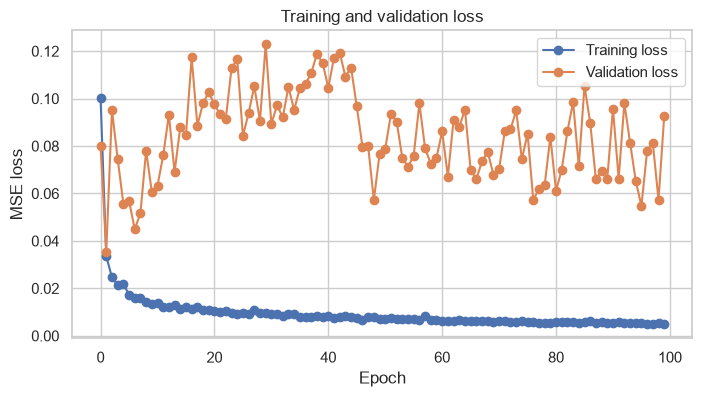

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(training_losses, marker="o", label="Training loss")
plt.plot(validation_losses, marker="o", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

## 6. Evaluation

Wir evaluieren auf dem Testbereich, der zeitlich nach Training und Validierung liegt. Zusätzlich vergleichen wir PatchTST mit zwei einfachen Baselines:

- **Naive Forecast:** Der letzte beobachtete Wert wird für alle Zukunftsschritte wiederholt.
- **Moving Average:** Der Durchschnitt der letzten 24 Stunden wird für alle Zukunftsschritte wiederholt.

Baselines sind wichtig, weil ein komplexes Modell nur dann überzeugend ist, wenn es einfache Regeln schlägt.

In [14]:
def collect_predictions(model, data_loader):
    # Collect model predictions and targets.
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for batch_inputs, batch_targets in data_loader:
            batch_inputs = batch_inputs.to(device)
            batch_predictions = model(batch_inputs).cpu().numpy()
            predictions.append(batch_predictions)
            targets.append(batch_targets.numpy())

    return np.concatenate(predictions), np.concatenate(targets)


patchtst_predictions_scaled, test_targets_scaled = collect_predictions(model, test_loader)

naive_predictions_scaled = np.repeat(X_test[:, -1:, :], repeats=horizon, axis=1)
moving_average_predictions_scaled = np.repeat(
    X_test[:, -24:, :].mean(axis=1, keepdims=True),
    repeats=horizon,
    axis=1,
)

def inverse_scale(scaled_values):
    # Transform scaled values back to the original units.
    return scaled_values * train_std.reshape(1, 1, -1) + train_mean.reshape(1, 1, -1)


patchtst_predictions = inverse_scale(patchtst_predictions_scaled)
naive_predictions = inverse_scale(naive_predictions_scaled)
moving_average_predictions = inverse_scale(moving_average_predictions_scaled)
test_targets = inverse_scale(test_targets_scaled)

print("Prediction shapes after evaluation:")
print(f"PatchTST predictions: {patchtst_predictions.shape} -> (test windows, forecast horizon, channels)")
print(f"Test targets:         {test_targets.shape} -> the true future values with the same shape")
print(f"Naive baseline:       {naive_predictions.shape} -> repeats the last observed value for all {horizon} future steps")
print(f"Moving average:       {moving_average_predictions.shape} -> repeats the mean of the last 24 observed steps")

Prediction shapes after evaluation:
PatchTST predictions: (855, 24, 1) -> (test windows, forecast horizon, channels)
Test targets:         (855, 24, 1) -> the true future values with the same shape
Naive baseline:       (855, 24, 1) -> repeats the last observed value for all 24 future steps
Moving average:       (855, 24, 1) -> repeats the mean of the last 24 observed steps


### Metriken

Wir verwenden:

- **MAE:** durchschnittlicher absoluter Fehler.
- **MSE:** durchschnittlicher quadratischer Fehler.
- **RMSE:** Wurzel aus MSE, wieder in Originaleinheit.
- **MAPE:** prozentualer Fehler. MAPE ist problematisch, wenn echte Werte nahe null liegen; hier ist das weniger kritisch.

In [15]:
def compute_metrics(y_true, y_pred):
    # Compute common regression metrics.
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    mse = mean_squared_error(y_true_flat, y_pred_flat)
    rmse = math.sqrt(mse)
    denominator = np.maximum(np.abs(y_true_flat), 1e-8)
    mape = np.mean(np.abs((y_true_flat - y_pred_flat) / denominator)) * 100
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE": mape}


target_slice = np.s_[:, :, target_index]

metrics_table = pd.DataFrame(
    {
        "PatchTST": compute_metrics(test_targets[target_slice], patchtst_predictions[target_slice]),
        "Naive": compute_metrics(test_targets[target_slice], naive_predictions[target_slice]),
        "Moving Average": compute_metrics(test_targets[target_slice], moving_average_predictions[target_slice]),
    }
).T

print(f"Metrics are computed only for target column '{target_column}'.")
print("MAE: average absolute error in the original unit; lower is better.")
print("MSE/RMSE: larger errors are penalized more strongly; RMSE is again in the original unit.")
print("MAPE: percentage error; it can become extremely large when true values are close to zero.")
print("Compare PatchTST with the baselines: the complex model is useful only if it beats simple rules.")
display(metrics_table.round(4))

Metrics are computed only for target column 'Close'.
MAE: average absolute error in the original unit; lower is better.
MSE/RMSE: larger errors are penalized more strongly; RMSE is again in the original unit.
MAPE: percentage error; it can become extremely large when true values are close to zero.
Compare PatchTST with the baselines: the complex model is useful only if it beats simple rules.


,MAE,MSE,RMSE,MAPE
PatchTST,1226.1450,2.475910e+06,1573.5026,35.8835
Naive,96.0140,2.295364e+04,151.5046,2.9675
Moving Average,129.5556,3.780609e+04,194.4379,3.9595


**Interpretation:** 

### Predicted vs. Actual

Wir visualisieren ein einzelnes Testfenster. Die Eingabe zeigt die Vergangenheit, danach vergleichen wir echte Zukunft und Prognosen.

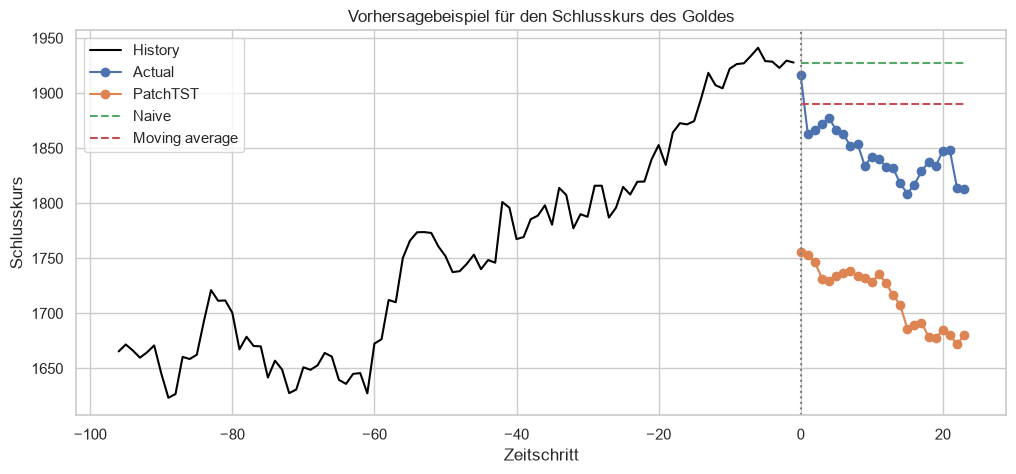

In [19]:
example_index = 10

history_scaled = X_test[example_index, :, target_index]
history = history_scaled * train_std[target_index] + train_mean[target_index]
actual_future = test_targets[example_index, :, target_index]
patchtst_future = patchtst_predictions[example_index, :, target_index]
naive_future = naive_predictions[example_index, :, target_index]
moving_average_future = moving_average_predictions[example_index, :, target_index]

history_axis = np.arange(-lookback, 0)
future_axis = np.arange(0, horizon)

plt.figure(figsize=(12, 5))
plt.plot(history_axis, history, label="History", color="black")
plt.plot(future_axis, actual_future, label="Actual", marker="o")
plt.plot(future_axis, patchtst_future, label="PatchTST", marker="o")
plt.plot(future_axis, naive_future, label="Naive", linestyle="--")
plt.plot(future_axis, moving_average_future, label="Moving average", linestyle="--")
plt.axvline(x=0, color="gray", linestyle=":")
plt.title("Vorhersagebeispiel für den Schlusskurs des Goldes")
plt.xlabel("Zeitschritt")
plt.ylabel("Schlusskurs")
plt.legend()
plt.show()

### Fehleranalyse nach Prognoseschritt

Viele Modelle sind für den ersten Zukunftsschritt besser als für spätere Schritte. Deshalb betrachten wir den MAE pro Horizontposition.

Step-wise MAE explanation:
Each point shows the average absolute error for one forecast step.
Step 1 is the first future time step; later steps are farther into the future and are often harder.
If PatchTST is above the Naive line, PatchTST is worse than simply repeating the last value at that horizon.


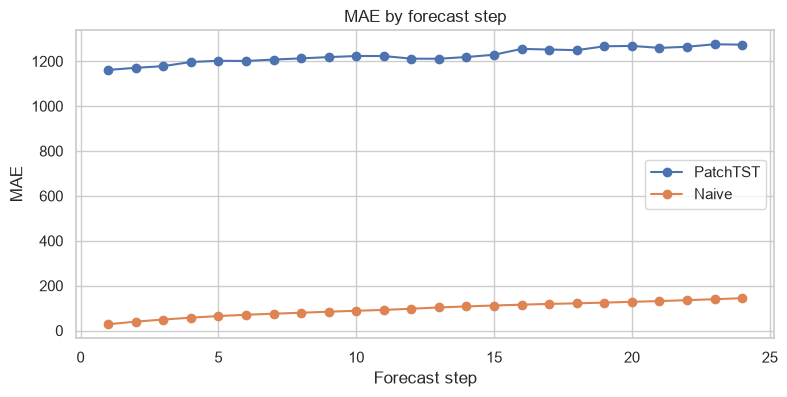

In [20]:
step_mae_patchtst = np.mean(
    np.abs(test_targets[target_slice] - patchtst_predictions[target_slice]),
    axis=0,
)
step_mae_naive = np.mean(
    np.abs(test_targets[target_slice] - naive_predictions[target_slice]),
    axis=0,
)

print("Step-wise MAE explanation:")
print("Each point shows the average absolute error for one forecast step.")
print("Step 1 is the first future time step; later steps are farther into the future and are often harder.")
print("If PatchTST is above the Naive line, PatchTST is worse than simply repeating the last value at that horizon.")

plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, horizon + 1), step_mae_patchtst, marker="o", label="PatchTST")
plt.plot(np.arange(1, horizon + 1), step_mae_naive, marker="o", label="Naive")
plt.title("MAE by forecast step")
plt.xlabel("Forecast step")
plt.ylabel("MAE")
plt.legend()
plt.show()